# 01 — Exploratory Data Analysis

WTI crude oil price and macro features. All logic lives in `src/`; this notebook only calls into it and plots.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_config
from src.pipeline import get_or_build_features

config = load_config()
df = get_or_build_features(config)
df.head()

,open,high,low,close,volume,dtwexbgs,dgs10,lag_1,lag_5,lag_20,ma_5,ma_20,ma_50,volatility_20,rsi_14,dtwexbgs_delta_5,dgs10_delta_5,target_reg,target_clf
date,,,,,,,,,,,,,,,,,,,
2019-03-14,58.349998,58.740002,58.000000,58.610001,567604,114.7900,2.63,58.259998,56.660000,53.900002,57.320,56.5400,53.9124,0.014519,56.980362,-0.7019,-0.01,58.520000,0
2019-03-15,58.509998,58.950001,57.740002,58.520000,507393,114.5815,2.59,58.610001,56.070000,54.410000,57.810,56.7455,54.1520,0.014521,69.047617,-0.7784,-0.03,59.090000,1
2019-03-18,58.450001,59.230000,58.049999,59.090000,157241,114.4375,2.60,58.520000,56.790001,55.590000,58.270,56.9205,54.3920,0.013980,71.043371,-0.8592,-0.04,59.029999,0
2019-03-19,59.009998,59.570000,58.619999,59.029999,114822,114.2324,2.61,59.090000,56.869999,56.090000,58.702,57.0675,54.6134,0.013939,64.615375,-0.7066,0.00,59.830002,1
2019-03-20,59.020000,60.119999,58.389999,59.830002,786342,114.1509,2.54,59.029999,58.259998,56.919998,59.016,57.2130,54.8396,0.013885,67.014333,-0.5863,-0.07,59.980000,1


## Price over time

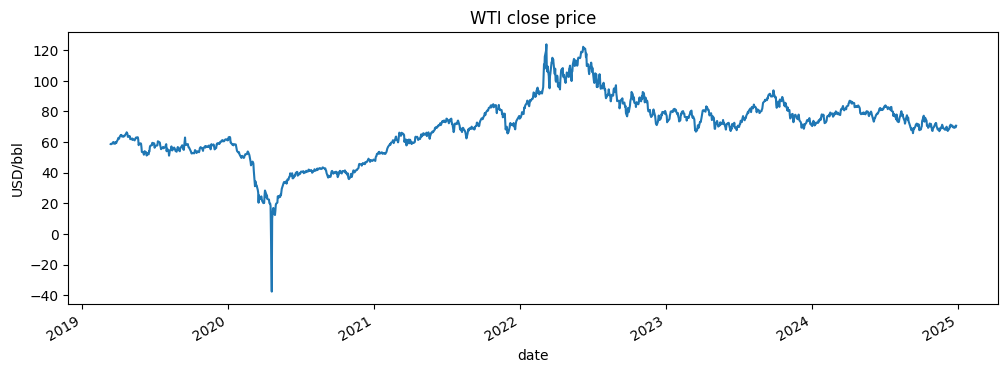

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
df["close"].plot(ax=ax, title="WTI close price")
ax.set_ylabel("USD/bbl")
plt.show()

## Correlation with macro features

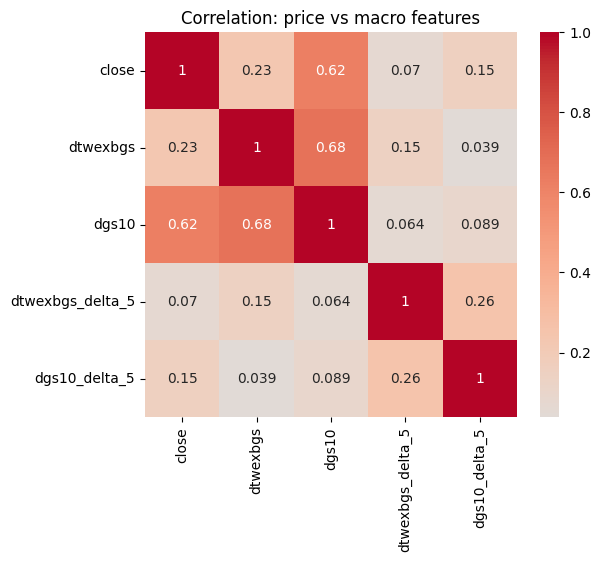

In [3]:
macro_cols = [c for c in df.columns if any(k in c for k in ["dtwexbgs", "dgs10"])]
corr = df[["close"] + macro_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: price vs macro features")
plt.show()

## Distribution of daily returns

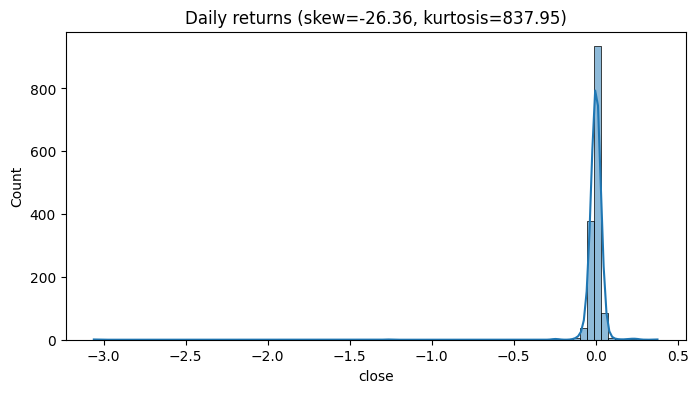

In [4]:
returns = df["close"].pct_change().dropna()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(returns, bins=80, kde=True, ax=ax)
ax.set_title(f"Daily returns (skew={returns.skew():.2f}, kurtosis={returns.kurt():.2f})")
plt.show()